In [1]:
# import os
# os.environ['JAX_PLATFORMS'] = 'cpu'

import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

# This is required to run multiple processes with JAX.
from multiprocessing import set_start_method
set_start_method('forkserver', force=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from tqdm import tqdm
from pathlib import Path

print(jax.devices())
jax.config.update("jax_debug_nans", True)

from config import Config
import data

[CudaDevice(id=0)]


In [3]:
cfg = Config.from_file("/nas/cee-water/cjgleason/ted/swot-ml/runs/test/swot.yml")
cfg.quiet = False

cache_mgr = data.DynamicCacheManager(cfg)
train_cache_dir = cache_mgr.create_cache('train')

Caches will be stored at: /scratch4/workspace/tlanghorst_umass_edu-swot-ml-zarr/zbs_batched/_cache/0fde0f99e94b8999
Indices for train already exist. Skipping.


In [4]:
import xarray as xr 

class FlatObservationDataset(data.CachedBasinGraphDataset):
    """
    Fully in-memory flat observation dataset for MLP training.
    Caches dynamic, target, static features and metadata.
    """

    def __init__(self, cfg: Config, cache_dir: Path, pad_size: int, subset: str , source_name: str):
        super().__init__(cfg, cache_dir, subset)
        
        if source_name not in self.features.dynamic:
            raise ValueError(f"Source '{source_name}' not found in config dynamic sources.")
        self.source_name = source_name
        self.source_columns = self.features.dynamic[source_name]
        self.samples = []

        for basin, subbasins in tqdm(self.basin_subset_dict.items(), desc="Caching basins in memory"):
            if not (self.cache_dir / basin).is_dir():
                print(f"{basin} not found in cache")
                continue
                
            with xr.open_zarr(self.cache_dir / basin, consolidated=True) as basin_ds:
                ds = basin_ds.sel(subbasin=basin_ds['subbasin'].isin(list(subbasins)))
                
                # Skip basins without required variables
                if not all(col in ds.data_vars for col in self.source_columns):
                    continue
                target_var = self.target[0]
                if target_var not in ds.data_vars:
                    continue

                ds = ds.load()
            
                x_dynamic = ds[self.source_columns]  # keep as DataArray for coords
                y = ds[self.target]
            
                valid_features = ~np.isnan(x_dynamic[self.source_columns[0]].values)
                valid_target = ~np.isnan(y.to_array().values[0,...])
                valid_mask = valid_features & valid_target

        
                for s_idx in range(valid_mask.shape[1]):
                    t_ids = np.where(valid_mask[:,s_idx])[0]
                    if len(t_ids) == 0:
                        continue
                    else:
                        subbasin_id = x_dynamic.subbasin.values[s_idx]

                        x_s = self.x_s.sel(subbasin=subbasin_id)[self.features.static].to_array().values.astype(np.float32)
                        
                        # Extract raw (normalized) data for current reach
                        x_d_raw = x_dynamic.isel(date=t_ids, subbasin=s_idx).to_array().values.T
                        y_arr_raw = y.isel(date=t_ids, subbasin=s_idx).to_array().values.T

                        # Extract and denormalize width and slope for filtering
                        # Width is index 1, Slope is index 2 in hws_cols
                        w_denorm = self.denormalize(x_dynamic['width_river'].isel(date=t_ids, subbasin=s_idx).values, 'width_river')
                        s_denorm = self.denormalize(x_dynamic['slope_river'].isel(date=t_ids, subbasin=s_idx).values, 'slope_river')
                        
                        # Identify valid indices where denormalized width and slope > 0
                        physical_mask = (w_denorm > 0) & (s_denorm > 0)
                        valid_t_indices = np.where(physical_mask)[0]
                        
                        if len(valid_t_indices) == 0:
                            continue

                        # Sub-select only physically valid timesteps
                        x_d = x_d_raw[valid_t_indices]
                        y_arr = y_arr_raw[valid_t_indices]
                        n_samples, n_features = x_d.shape
                        
                        if n_samples > pad_size:
                            raise ValueError(f"pad_size ({pad_size}) exceeded by {n_samples} samples.")
                        
                        # Padding logic
                        x_pad = np.ones((pad_size, n_features), dtype=x_d.dtype)
                        x_pad[:n_samples, :] = x_d
                        
                        mask = np.zeros((pad_size, n_features), dtype=np.int8)
                        mask[:n_samples, :] = 1
                        
                        y_pad = np.ones((pad_size, y_arr.shape[1]), dtype=x_d.dtype)
                        y_pad[:n_samples, :] = y_arr
                        
                        # Construct hws with denormalized values for valid indices
                        hws_cols = ['d_wse_river', 'width_river', 'slope_river']
                        hws_arr = x_dynamic[hws_cols].isel(date=t_ids, subbasin=s_idx).to_array().values.T[valid_t_indices]
                        
                        for i, col in enumerate(hws_cols):
                            hws_arr[:, i] = self.denormalize(hws_arr[:, i], col)
                        
                        hws_pad = np.ones((pad_size, hws_arr.shape[1]), dtype=x_d.dtype)
                        hws_pad[:n_samples, :] = hws_arr
                        
                        reach_sample = {
                            'basin': basin,
                            'subbasin': subbasin_id,
                            'x_d': x_pad,
                            'd_mask': mask,
                            'x_s': x_s,
                            'hws': hws_pad,
                            'y': y_pad 
                        }
                        self.samples.append(reach_sample)

        
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int):
        return self.samples[idx]
        

train_dataset = FlatObservationDataset(cfg, train_cache_dir, 200, 'train', 'swot-river')

Calculating training statistics for encoding and normalization...
Loading basin graphs...Done!
Loading optimized indices for train...Done!


Caching basins in memory: 100%|██████████| 1182/1182 [03:52<00:00,  5.07it/s]


In [226]:
from torch.utils.data import DataLoader

def collate_flat_jax(samples):
    basin = [s['basin'] for s in samples]
    subbasin = [s['subbasin'] for s in samples]
    x_d = jnp.array([s['x_d'] for s in samples])
    d_mask = jnp.array([s['d_mask'] for s in samples])
    x_s = jnp.array([s['x_s'] for s in samples])
    hws = jnp.array([s['hws'] for s in samples])
    y = jnp.array([s['y'] for s in samples])
    return basin, subbasin, x_d, d_mask, x_s, hws, y

# train_dataset = FlatObservationDataset(cfg, train_cache_dir, 'train', 'swot-river')
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_flat_jax)

In [44]:
import equinox as eqx

class ReachParameterNet(eqx.Module):
    A0_net: eqx.nn.MLP
    n_net: eqx.nn.MLP

    def __init__(self, in_size, hidden_size, depth, *, key):
        k1, k2 = jax.random.split(key)
        # Separate heads to eliminate parameter interference
        self.A0_net = eqx.nn.MLP(
            in_size=in_size,
            out_size=1,
            width_size=hidden_size,
            depth=depth,
            key=k1
        )
        self.n_net = eqx.nn.MLP(
            in_size=in_size,
            out_size=1,
            width_size=hidden_size,
            depth=depth,
            key=k2
        )
    
    def __call__(self, x_d, d_mask, x_s, hws):

        def get_params(x_temporal):
            feat = jnp.concat([x_temporal, x_s])
            return jnp.concat([self.A0_net(feat), self.n_net(feat)])

        embeddings = jax.vmap(get_params)(x_d)
        params = jnp.mean(embeddings, axis=0, where=d_mask[:, None])

        dh = hws[:, 0]
        w = hws[:, 1]
        s = hws[:, 2]
        dA = w * dh

        # A0 scaled by mean width to provide physical context
        avg_w = jnp.mean(w, where=d_mask)
        A0_depth = jax.nn.softplus(params[0]) 
        A0 = (A0_depth * avg_w) - jnp.min(dA) + 1e-6
        A = A0 + dA

        # soft, symmetric mapping of latent states 
        n_center = 0.3     
        n_half_range = 0.299
        n = n_center + n_half_range * jnp.tanh(params[1])

        Q = (1/n) * jnp.power(A, 5/3) * jnp.power(w, -2/3) * jnp.sqrt(s)

        return Q, A0, n


@eqx.filter_value_and_grad
def log_mse_loss(model, x_d, d_mask, x_s, hws, y, norm_fn):
    y_hat, _, _ = jax.vmap(model)(x_d, d_mask, x_s, hws)
    err = norm_fn(y_hat) - y
    return jnp.nanmean(jnp.nanmean(err**2, axis=1, where=d_mask))

@eqx.filter_value_and_grad
def nse_loss(model, x_d, d_mask, x_s, hws, y, denorm_fn):
    y_hat, _, _ = jax.vmap(model)(x_d, d_mask, x_s, hws)
    y_obs = denorm_fn(y)

    sq_error = jnp.square(y_obs - y_hat) * d_mask
    mse = jnp.mean(sq_error, axis=1)  # mean squared errors per basin
    
    std_y = jnp.std(y_obs, axis=1, where=d_mask.astype(bool))  # Per-basin standard deviation
    stable_std_y = jnp.nan_to_num(std_y) + 0.1
    denom = jnp.square(stable_std_y)

    return jnp.mean(mse / denom)



In [24]:
y_hat

Array([[4.9468967e+01, 1.0751466e+05, 1.0751466e+05, ..., 1.0751466e+05,
        1.0751466e+05, 1.0751466e+05],
       [8.7488846e+01, 7.6166809e+01, 6.4645172e+01, ..., 4.7842300e+05,
        4.7842300e+05, 4.7842300e+05],
       [6.4266858e+00, 5.4280894e+03, 5.4280894e+03, ..., 5.4280894e+03,
        5.4280894e+03, 5.4280894e+03],
       ...,
       [1.7934303e+01, 3.3268368e+01, 3.4256176e+01, ..., 1.3603162e+04,
        1.3603162e+04, 1.3603162e+04],
       [2.0026365e+01, 1.6042786e+01, 1.5389408e+01, ..., 5.5783949e+04,
        5.5783949e+04, 5.5783949e+04],
       [1.2165457e+01, 5.5241523e+00, 6.4146323e+00, ..., 2.3615833e+03,
        2.3615833e+03, 2.3615833e+03]], dtype=float32)

In [7]:
sample = train_dataset[0]
d_size = sample['x_d'].shape[-1]
s_size = sample['x_s'].shape[-1]

in_size = d_size + s_size
out_size = 1

In [104]:
for batch in train_loader:
    basin, subbasin, x_d, d_mask, x_s, hws, y = batch
    d_mask = d_mask[..., 0] #bandaid
    y = y[...,0]
    break

key = jax.random.PRNGKey(0)
model = ReachParameterNet(in_size, 128, 2, key=key)

y_hat, A0, n = jax.vmap(model)(x_d, d_mask, x_s, hws)


In [51]:
denorm_fn = partial(train_dataset.denormalize, name='discharge')

y_obs = denorm_fn(y)

sq_error = jnp.square(y_obs - y_hat) *d_mask
mse = jnp.mean(sq_error, axis=1)  # mean squared errors per basin

std_y = jnp.std(y_obs, axis=1, where=d_mask.astype(bool))  # Per-basin standard deviation
stable_std_y = jnp.nan_to_num(std_y) + 0.1
denom = jnp.square(stable_std_y)

nse = mse / denom
jnp.mean(node_nse)


Array(1960.0703, dtype=float32)

In [52]:
y_obs

Array([[184.90894  , 161.40599  , 171.60007  , ...,  51.910316 ,
         51.910316 ,  51.910316 ],
       [ 44.9      ,  57.099976 , 277.99985  , ...,  51.910316 ,
         51.910316 ,  51.910316 ],
       [ 13.699998 ,  10.800001 ,   7.2699995, ...,  51.910316 ,
         51.910316 ,  51.910316 ],
       ...,
       [257.9664   , 404.9308   ,  51.910316 , ...,  51.910316 ,
         51.910316 ,  51.910316 ],
       [ 35.96239  ,  52.66932  ,  46.722794 , ...,  51.910316 ,
         51.910316 ,  51.910316 ],
       [ 45.14599  ,  15.333997 , 763.02856  , ...,  51.910316 ,
         51.910316 ,  51.910316 ]], dtype=float32)

In [227]:
import optax
from functools import partial

jax.config.update("jax_debug_nans", True)

key = jax.random.PRNGKey(0)
model = ReachParameterNet(in_size, 256, 4, key=key)

optim = optax.adam(0.00003)
trainable_model = eqx.filter(model, eqx.is_array)
opt_state = optim.init(trainable_model)


@eqx.filter_jit
def make_step(model, x_d, d_mask, x_s, hws, y, norm_fn, denorm_fn, opt_state):
    # loss, grads = log_mse_loss(model, x_d, d_mask, x_s, hws, y, norm_fn)
    loss, grads = nse_loss(model, x_d, d_mask, x_s, hws, y, denorm_fn)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state


losses = []
target_norm_fn = partial(train_dataset.normalize, name='discharge')
target_denorm_fn = partial(train_dataset.denormalize, name='discharge')

epoch_iter = tqdm(range(500), desc='Epoch:')
for epoch in epoch_iter:
    e_losses = []
    for batch in train_loader:
        basin, subbasin, x_d, d_mask, x_s, hws, y = batch
        d_mask = d_mask[..., 0] #bandaid
        y = y[...,0]

        
        loss, model, opt_state = make_step(model, x_d, d_mask, x_s, hws, y, target_norm_fn, target_denorm_fn, opt_state)
        e_losses.append(loss.item())
        
    
    loss = np.mean(e_losses)
    losses.append(loss)

    epoch_iter.set_postfix_str(f"{loss = :0.4f}")

    # if epoch % 50 == 0:
    #     print(f"{epoch = }, {loss = :0.4f}")


Epoch:: 100%|██████████| 500/500 [05:15<00:00,  1.58it/s, loss = 86.8003]  


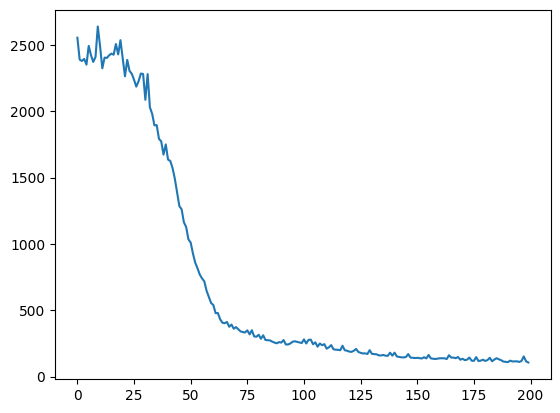

In [222]:
plt.plot(losses)

In [223]:
y_hat, A0, n = jax.vmap(model)(x_d, d_mask, x_s, hws)

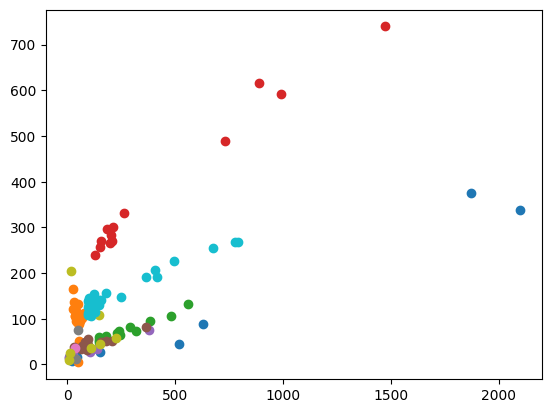

In [224]:
y_denorm = train_dataset.denormalize(y, 'discharge')


for reach_idx in range(10):
    mask_ids = np.where(d_mask[reach_idx, :])
    y_h = y_hat[reach_idx, mask_ids]
    y_o = y_denorm[reach_idx, mask_ids]

    plt.scatter(y_o, y_h)


(array([12., 26., 16., 21., 24., 20., 25., 18., 12., 10.]),
 array([0.03450689, 0.08886555, 0.14322421, 0.19758286, 0.25194153,
        0.30630016, 0.36065882, 0.41501749, 0.46937615, 0.52373481,
        0.57809347]),
 <BarContainer object of 10 artists>)

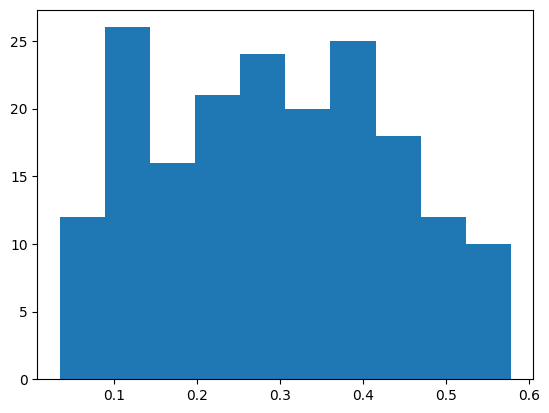

In [73]:
plt.hist(n)

In [75]:
test_cache_dir = cache_mgr.create_cache('test')
test_dataset = FlatObservationDataset(cfg, train_cache_dir, 200, 'test', 'swot-river')
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=True, collate_fn=collate_flat_jax)


Indices for test already exist. Skipping.
Calculating training statistics for encoding and normalization...
Loading basin graphs...Done!
Loading optimized indices for test...Done!


Caching basins in memory:   0%|          | 0/720 [00:00<?, ?it/s]

ABOM-100288010 not found in cache
ABOM-10046010 not found in cache
ABOM-110531010 not found in cache


Caching basins in memory:   1%|          | 5/720 [00:00<01:06, 10.78it/s]

ABOM-119883010 not found in cache


...

USGS-15565700 not found in cache
USGS-15747000 not found in cache


Caching basins in memory:  99%|█████████▉| 712/720 [02:52<00:01,  6.79it/s]

USGS-50028000 not found in cache


Caching basins in memory: 100%|██████████| 720/720 [02:53<00:00,  4.15it/s]

USGS-50071000 not found in cache
USGS-50083500 not found in cache
USGS-50093120 not found in cache
USGS-50129254 not found in cache


In [197]:
subbasin_list = []
y_list = []
y_pred_list = []
A0_list = []
n_list = []
h_list = []
w_list = []
s_list = []

for batch in tqdm(train_loader):
    basin, subbasin, x_d, d_mask, x_s, hws, y = batch
    d_mask = d_mask[..., 0] #bandaid
    y = y[...,0]

    y_hat, A0, n = jax.vmap(model)(x_d, d_mask, x_s, hws)

    y = test_dataset.denormalize(y, 'discharge')

    for i in range(y.shape[0]):
        mask_ids = np.where(d_mask[i,:])[0]
        n_obs = len(mask_ids)

        subbasin_list.append(np.tile(subbasin[i], n_obs))
        y_list.append(y[i, mask_ids])
        y_pred_list.append(y_hat[i, mask_ids])
        A0_list.append(np.tile(A0[i], n_obs))
        n_list.append(np.tile(n[i], n_obs))
        h_list.append(hws[i,mask_ids,0])
        w_list.append(hws[i,mask_ids,1])
        s_list.append(hws[i,mask_ids,2])

pred_data = {
    'subbasin': np.concatenate(subbasin_list),
    'y': np.concatenate(y_list),
    'y_pred': np.concatenate(y_pred_list),
    'A0': np.concatenate(A0_list),
    'n': np.concatenate(n_list),
    'h': np.concatenate(h_list),
    'w': np.concatenate(w_list),
    's': np.concatenate(s_list),
}

results = pd.DataFrame(pred_data)

100%|██████████| 6/6 [00:30<00:00,  5.08s/it]


In [198]:
results

,subbasin,y,y_pred,A0,n,h,w,s
0,USGS-04065106,36.528732,36.262714,359.386566,0.415204,-0.25840,174.614532,0.001048
1,ECCC-03QC002,19.573954,9.880506,140.824997,0.570424,-0.44280,100.762405,0.003650
2,ECCC-03QC002,11.146873,7.721963,140.824997,0.570424,-0.74450,84.833717,0.003618
3,ECCC-03QC002,8.885936,9.861037,140.824997,0.570424,-0.53980,90.160477,0.003618
4,ECCC-03QC002,6.967707,8.440497,140.824997,0.570424,-0.55820,97.382980,0.003633
...,...,...,...,...,...,...,...,...
22750,USGS-05422000,16.197233,18.124670,160.164612,0.279886,0.01785,83.157143,0.000406
22751,USGS-05422000,18.009514,29.167568,160.164612,0.279886,0.08905,41.945847,0.000403
22752,USGS-05422000,17.811296,33.252975,160.164612,0.279886,-0.14565,30.447672,0.000405
22753,USGS-05422000,16.452085,16.775572,160.164612,0.279886,-0.14005,76.158951,0.000401


In [196]:
h_list == w_list

True

In [155]:
from evaluate import metrics

def get_nse(grp):
    y = grp['y']
    y_pred = grp['y_pred']

    kge_results = metrics.calc_kge(y, y_pred)
    if isinstance(kge_results, tuple):
        kge, corr, alpha, beta = kge_results
    else:
        kge = corr = alpha = beta = np.nan
    out = {
        'kge': kge,
        'corr': corr,
        'alpha': alpha,
        'beta': beta
    }
    return pd.Series(out)
    
kge = results.groupby('subbasin').apply(get_nse, include_groups=False).dropna()

/nas/cee-water/cjgleason/ted/swot-ml/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/nas/cee-water/cjgleason/ted/swot-ml/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [208]:
def get_corr(grp):
    return np.corrcoef(grp['y'], grp['h'])[0, 1]

h_corr = results.groupby('subbasin').apply(get_corr, include_groups=False)
h_corr

/nas/cee-water/cjgleason/ted/swot-ml/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/nas/cee-water/cjgleason/ted/swot-ml/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/nas/cee-water/cjgleason/ted/swot-ml/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/nas/cee-water/cjgleason/ted/swot-ml/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/nas/cee-water/cjgleason/ted/swot-ml/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


subbasin
ABOM-11748010           0.999386
ABOM-12049010                NaN
ABOM-121206010               NaN
ABOM-123864010          0.994411
ABOM-127847010          0.974437
                          ...   
USGS-15580095           0.911658
USGS-15744500           0.915286
USGS-15908000          -0.022036
USGS-383103106594200    0.968841
USGS-50055000                NaN
Length: 1464, dtype: float64

In [213]:
kge.join(h_corr.rename('h_corr'))

,kge,corr,alpha,beta,h_corr
subbasin,,,,,
ABOM-11748010,-0.098186,0.998621,0.209766,0.237411,0.999386
ABOM-123864010,-0.237718,0.607641,0.043764,0.319108,0.994411
ABOM-127847010,0.646230,0.998845,0.662588,0.893673,0.974437
ABOM-128547010,0.023423,1.000000,0.444494,0.196809,1.000000
ABOM-133975010,-2.608307,-0.950789,0.520659,3.997422,0.989291
...,...,...,...,...,...
USGS-15565447,-0.343564,0.896489,0.051939,0.053623,0.893980
USGS-15580095,-0.092265,0.671915,0.103118,0.469900,0.911658
USGS-15744500,-0.138474,0.409415,0.185336,0.467408,0.915286


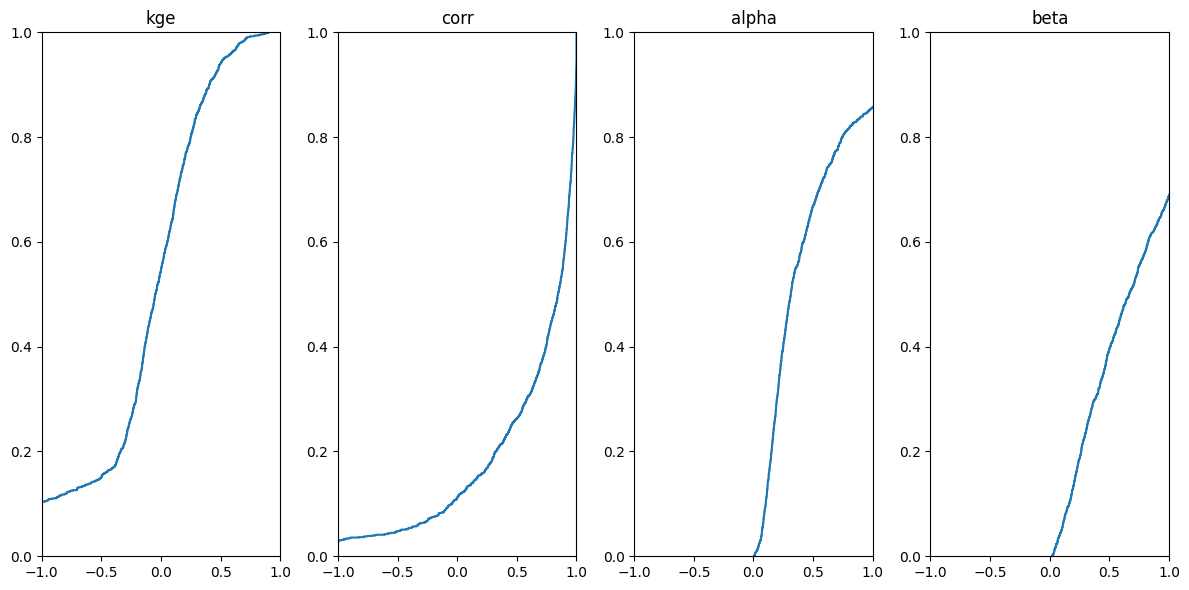

In [210]:
fig, axes = plt.subplots(1,4, figsize=(12,6))
for c, ax in zip(kge.columns, axes):
    y = kge[c]
    ax.ecdf(y)
    ax.set_xlim([-1, 1])
    ax.set_title(c)

fig.tight_layout()

In [171]:
kge.sort_values('kge')

,kge,corr,alpha,beta
subbasin,,,,
UKEA-F3505,-642.200971,-0.033938,588.603027,262.589569
BRANA-30058000,-159.043631,-0.241298,109.041061,119.065880
UKEA-713056,-58.151291,0.446260,54.744312,25.700556
EAUF-A9301080,-49.319405,-0.250136,40.737499,31.844948
EAUF-O4931010,-45.408552,0.920318,46.633888,9.443673
...,...,...,...,...
BRANA-45960001,0.861531,0.875809,1.059304,0.984727
EAUF-L6020710,0.872271,0.977473,0.920227,0.902822
BRANA-14550000,0.875139,0.996632,0.955644,1.116668


<Axes: xlabel='y', ylabel='y_pred'>

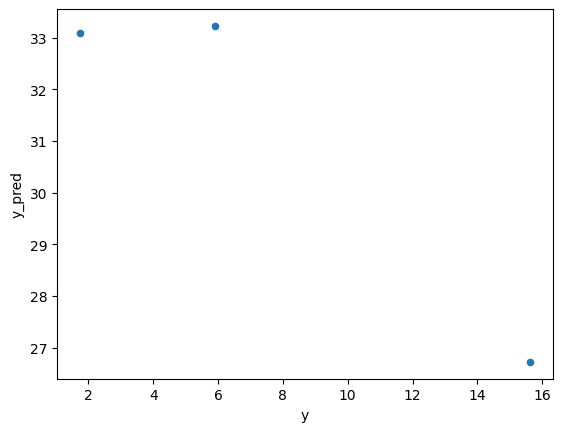

In [214]:
basin_results = results[results['subbasin'] == 'ABOM-133975010']

basin_results.plot.scatter('y','y_pred')

In [215]:
basin_results

,subbasin,y,y_pred,A0,n,h,w,s
762,ABOM-133975010,1.727000,33.094036,190.599609,0.295931,-0.9093,47.417828,0.000971
763,ABOM-133975010,5.908000,33.226742,190.599609,0.295931,-0.6750,51.860363,0.000923
764,ABOM-133975010,15.640998,26.723200,190.599609,0.295931,-0.3652,77.347626,0.000883


In [168]:
y_obs

Array([ 460.4009 ,  421.3529 ,  338.98297,  304.862  ,  421.3529 ,
        384.53787, 2065.9692 , 2118.2292 , 2344.2092 , 1191.4497 ,
        984.8622 ,  507.94205,  420.52075,  314.83484,  240.09795,
        184.77193,  159.74292,  161.96196,  228.60191,  346.81085,
        369.27185,  653.14795,  911.5111 ], dtype=float32)